# Preliminary Results

## Ryan Waterman
## 8/7/2025

## Feature Engineering Plan 

Many of the existing features in the dataset lend themselves to transformation, which could improve model performance. There are six variables that have been identified as candidates for transformation, or as the basis for new features: Total_Revolving_Bal, Credit_Limit, Avg_Utilization_Ratio, Total_Trans_Amt, Months_on_book, and Total_Trans_Ct. Additional experimentation would be required, but Avg_Utilization_Ratio has a non-linear relationship with Credit_Limit and Avg_Open_To_Buy, therefore a log transformation may aid in the relevance and predictive impact of this variable. 

The ratio between Total Revolving Balance and Total Transaction Count could be added as a new feature, which would provide information about the customer’s spending habits. A high revolving balance to transaction count ratio would imply the customer is spending large amounts with few transactions, or vice versa, which may have an impact on churn rate. This variable would be called Balance_To_TC. 

Another feature that could be added is the proportion of Income Category that Credit Limit makes up. The income categories would be reduced to numerical representations, likely using a bin size adjusted mean income per income category. If customers have obtained a high credit limit relative to their income, it can be assumed they have high credit scores, for which the number of open accounts in good standing is a factor. A high number of open accounts in good standing implies the customer may be less likely to close their account. This variable would be called Credit_Limit_per_Income. 

Average Utilization Ratio, Total Transaction Amount, and Credit Limit can be compounded to identify the multiple of a given customer’s average balance is being transacted annually. Average Utilization Ratio multiplied by Credit Limit would result in the average balance carried on the card, which Total Transaction Amount could be divided by. The resulting feature would be an indication of how capable the customer is of paying their balance, normalized to their credit limit. This variable would be called Leveraged_Balance_Ratio. 

Lastly, the number of Months on Book can be multiplied by the Total Relationship Count (number of products held by the customer) to create a variable that represents the strength of the relationship the customer has with the bank. A higher value indicates a stronger relationship, as customers that are heavily invested in the products and services the bank provides may be less likely to stop utilizing the bank. This variable would be called Relationship_Strength. 

In [251]:
import pandas as pd
import matplotlib.pyplot as plt

In [252]:
data = pd.read_csv('./customer_data/customer_data.csv')

In [253]:
data.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### Step 1: Adding Features

As stated in the Feature Engineering Plan, above, several features can be added to the dataset. These features are derived from existing variables.

1. Balance_To_TC = (Total Revolving Balance) / (Total Transaction Count)

2. Credit_Limit_per_Income = (Credit Limit) / (Mean(Income Category))

3. Leveraged_Balance_Ratio = (Total Transaction Amount) / (Average Utilization Ratio * Credit Limit)

4. Relationship_Strength = Months on Book * Total Relationship Count

### Adding Balance_To_TC

In [254]:
# Add the Balance_To_TC variable
data['Balance_To_TC'] = data['Total_Revolving_Bal'] / data['Total_Trans_Ct']
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,18.500000
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,26.181818


### Adding Credit_Limit_per_Income

In [255]:
# Add the Credit_Limit_per_Income variable
# This will take some effort to remap the income category variable to a numerical value
data['Income_Category'].unique()

array(['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'Unknown'], dtype=object)

It appears the Income_Category variable has to be modified to properly categorize it in a numerical format. This requires a bit more exploration first.

<Axes: >

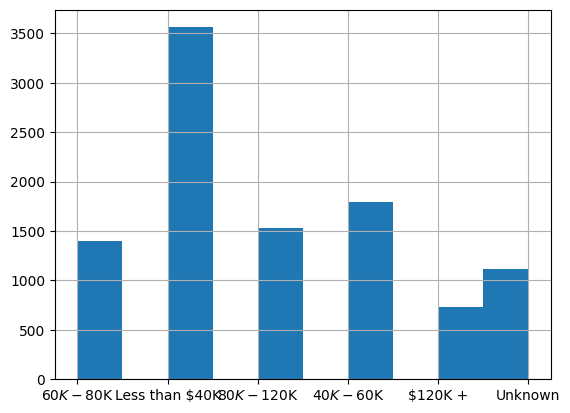

In [256]:
data['Income_Category'].hist()

In [257]:
data['Income_Category'].value_counts()

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

In [258]:
data[['Income_Category', 'Credit_Limit']].groupby(['Income_Category']).mean()

,Credit_Limit
Income_Category,
$120K +,19717.322558
$40K - $60K,5462.259832
$60K - $80K,10758.772967
$80K - $120K,15809.890945
Less than $40K,3754.404521
Unknown,9516.582464


In [259]:
data[['Income_Category', 'Credit_Limit']].groupby(['Income_Category']).std()

,Credit_Limit
Income_Category,
$120K +,12064.309210
$40K - $60K,4557.471801
$60K - $80K,8862.475017
$80K - $120K,11259.665550
Less than $40K,2759.888288
Unknown,8677.921738


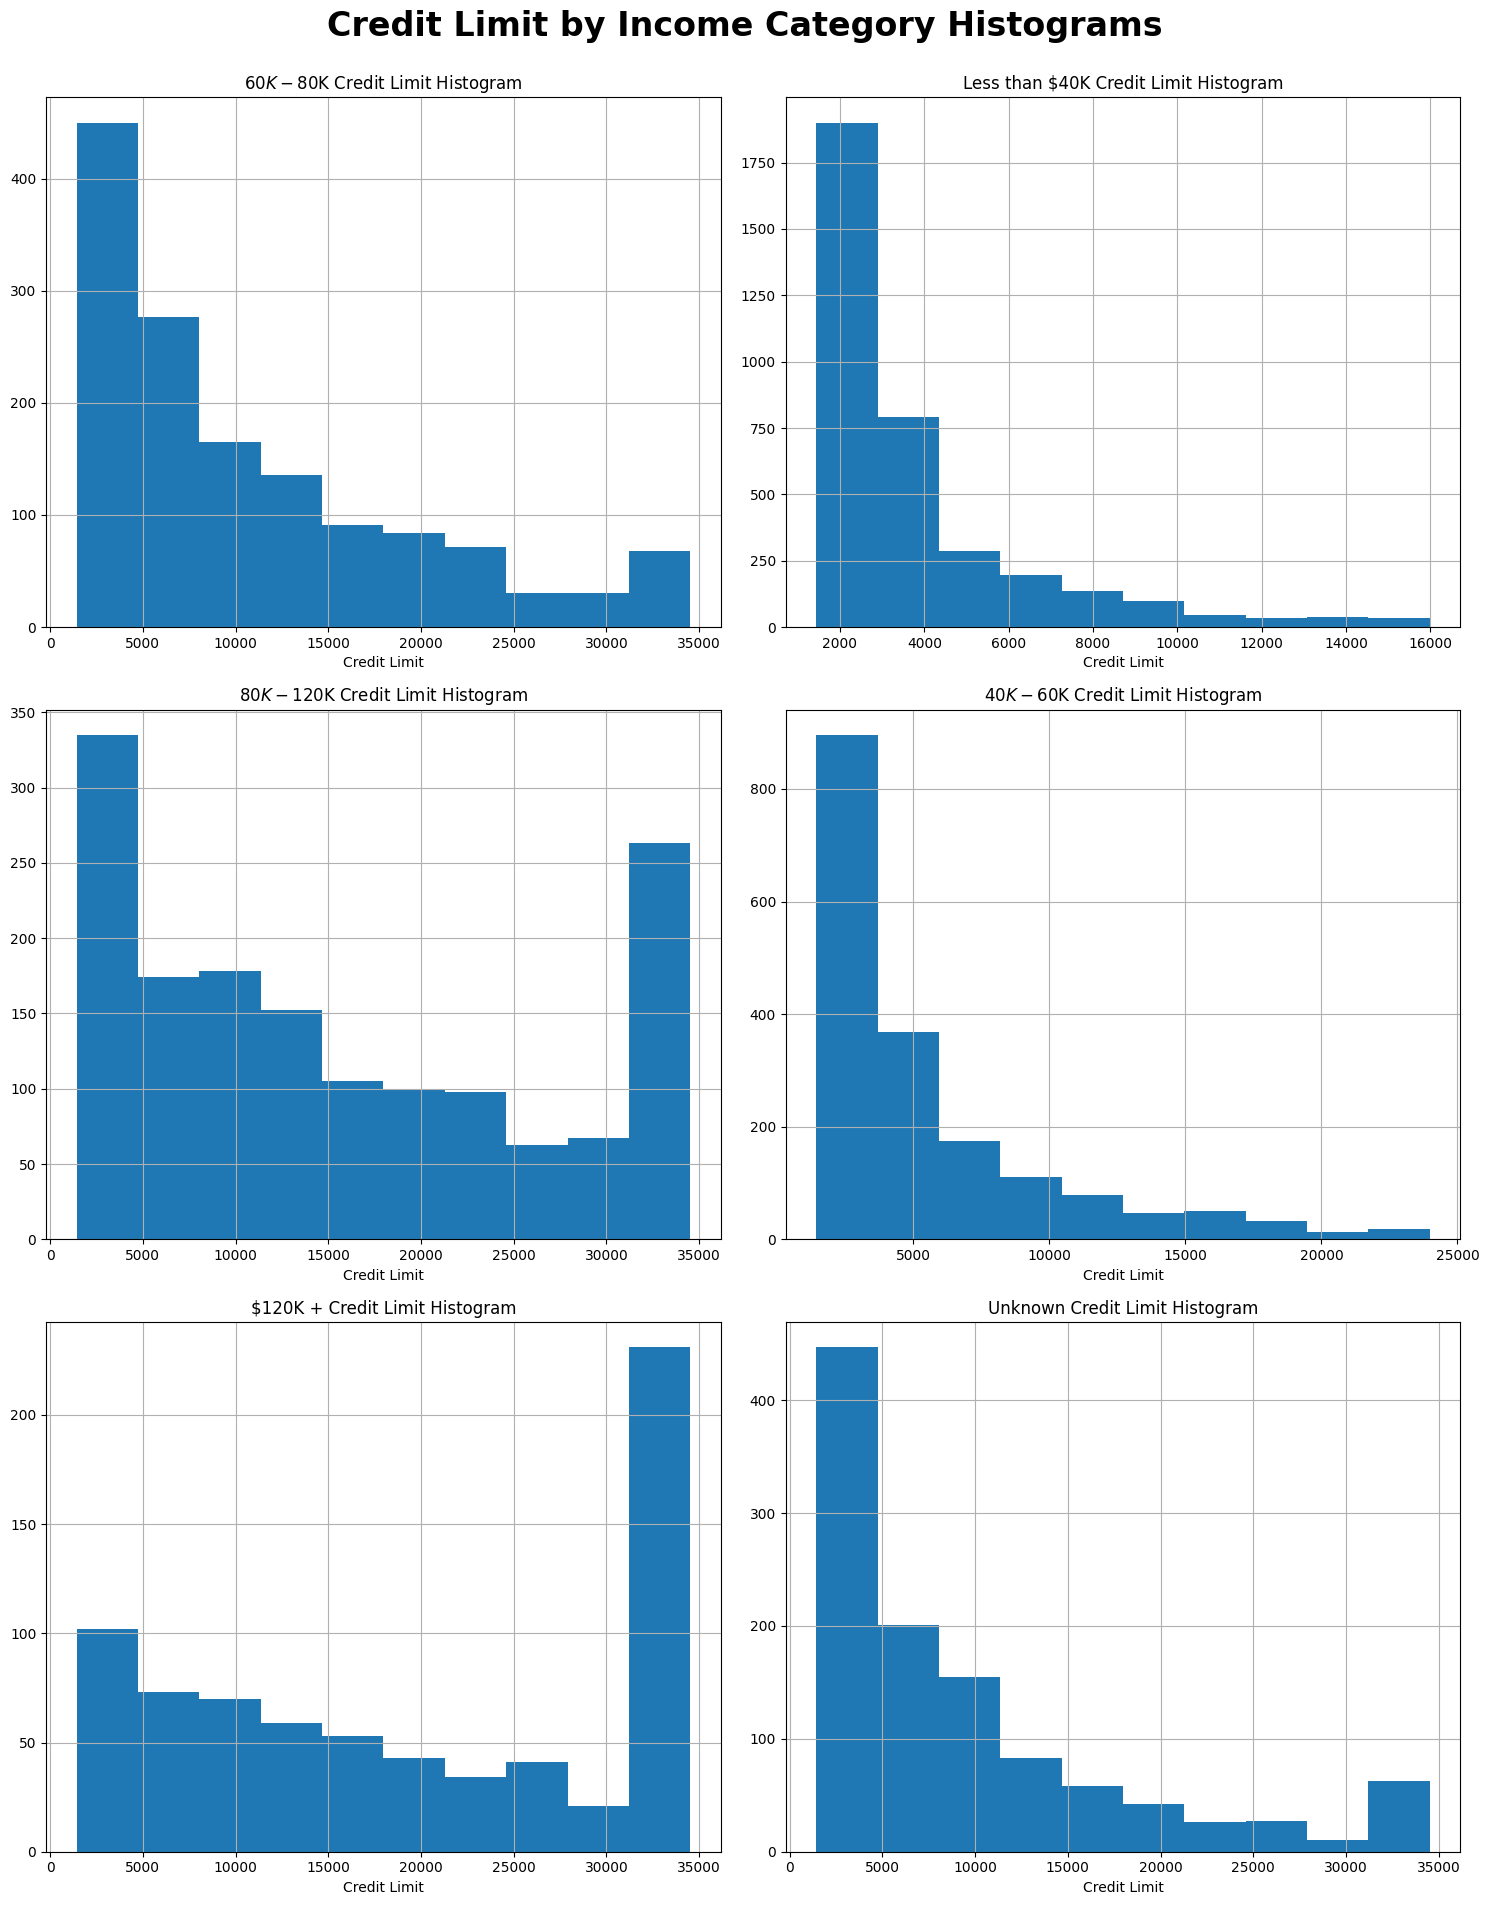

In [260]:
fig, axes = plt.subplots(3,2,figsize = (15, 20))
axes = axes.flatten()

fig.suptitle('Credit Limit by Income Category Histograms', fontsize = 24, fontweight = 'bold')

for i, cat in enumerate(data['Income_Category'].unique()):

    filtered = data[data['Income_Category']==cat]
    filtered['Credit_Limit'].hist(ax=axes[i])
    
    # Add title and axis label
    axes[i].set_title(f'{cat} Credit Limit Histogram') 
    axes[i].set_xlabel('Credit Limit') 
    
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Show the plot
plt.show()




The takeaway from these histograms is that the credit limits are non-normally distributed, so synthetic data cannot be generated based on a gaussian distrubution. Instead what I will do is create discrete income values using the proportion of credit limits for each category.

In [261]:
data['Income_Category'].replace('$0 - $40k', '$0k - $40k', inplace=True)

C:\Users\water\AppData\Local\Temp\ipykernel_24540\3152297738.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Income_Category'].replace('$0 - $40k', '$0k - $40k', inplace=True)


In [262]:
income_data = {}

for cat in sorted(data['Income_Category'].unique()):
    income_data[cat] = {}

    # First filter by the current category
    filtered = data[data['Income_Category']==cat]

    bins = [bin for bin in range(0, int(max(filtered['Credit_Limit'])), int(max(filtered['Credit_Limit'])/10))]
    labels = []

    for i in range(len(bins)-1):
        if i == len(bins) - 2:
            labels.append(f'${bins[-2]} +')
        else:
            labels.append(f'${bins[i]} - ${bins[i+1]}')


    # Then, bin the credit limits for the category
    binned = pd.cut(filtered['Credit_Limit'], bins=bins, labels=labels).value_counts()

    for i in range(len(binned)):
        income_data[cat] = binned

income_data      

{'$120K +': Credit_Limit
 $6902 - $10353     80
 $3451 - $6902      78
 $0 - $3451         69
 $10353 - $13804    66
 $13804 - $17255    54
 $24157 - $27608    46
 $17255 - $20706    42
 $20706 - $24157    34
 $31059 +           28
 $27608 - $31059    27
 Name: count, dtype: int64,
 '$40K - $60K': Credit_Limit
 $2398 - $4796      681
 $0 - $2398         428
 $4796 - $7194      264
 $7194 - $9592      144
 $9592 - $11990      95
 $14388 - $16786     56
 $11990 - $14388     52
 $16786 - $19184     35
 $19184 - $21582     15
 $21582 +             8
 Name: count, dtype: int64,
 '$60K - $80K': Credit_Limit
 $0 - $3451         331
 $3451 - $6902      315
 $6902 - $10353     214
 $10353 - $13804    135
 $13804 - $17255    103
 $17255 - $20706     88
 $20706 - $24157     79
 $24157 - $27608     37
 $27608 - $31059     32
 $31059 +            19
 Name: count, dtype: int64,
 '$80K - $120K': Credit_Limit
 $3451 - $6902      237
 $0 - $3451         218
 $6902 - $10353     188
 $10353 - $13804    1

In [263]:
#Establish a delta range for each 
deltas = {
    '$0k - $40k':40000,
    '$40K - $60K':20000,
    '$60K - $80K':20000,
    '$80K - $120K':40000,
    'Unknown':160000,
    '$120K +':40000
          }

In [264]:
print(sorted(data['Income_Category'].unique()))

['$120K +', '$40K - $60K', '$60K - $80K', '$80K - $120K', 'Less than $40K', 'Unknown']


### Adding Leveraged_Balance_Ratio

Leveraged_Balance_Ratio = (Total Transaction Amount) / (Average Utilization Ratio * Credit Limit)

In [265]:
data['Leveraged_Balance_Ratio'] = (data['Avg_Utilization_Ratio']*data['Credit_Limit'])/data['Total_Trans_Amt']

In [266]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Leveraged_Balance_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,18.500000,0.676705
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,26.181818,0.671479


### Adding Relationship_Strength 

Relationship_Strength = Months on Book * Total Relationship Count

In [267]:
data['Relationship_Strength'] = data['Months_on_book']*data['Total_Relationship_Count']

In [268]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Leveraged_Balance_Ratio,Relationship_Strength
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,777,11914.0,1.335,1144,42,1.625,0.061,18.500000,0.676705,195
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,864,7392.0,1.541,1291,33,3.714,0.105,26.181818,0.671479,264


## Select Variables

| Variable | Type |
|-------------|-------------|
| Contacts_Count_12_mon | Quantitative| 
| Total_Revolving_Bal | Quantitative |
| Total_Amt_Chng_Q4_Q1 | Quantitative |
| Total_Trans_Amt | Quantitative |
| Total_Trans_Ct | Quantitative |
| Total_Ct_Chng_Q4_Q1 | Quantitative |
| Avg_Utilization_Ratio | Quantitative |
| Balance_To_TC | Quantitative |
| Credit_Limit_per_Income | Quantitative |
| Leveraged_Balance_Ratio | Quantitative |
| Relationship_Strength | Quantitative |
| Income_Category | Categorical |
| Gender | Categorical |
| Education_Level | Categorical| 
| Marital_Status | Categorical| 
| Card_Category | Categorical|

In [269]:
columns_to_keep = set(['Attrition_Flag', "Contacts_Count_12_mon", "Total_Revolving_Bal", "Total_Amt_Chng_Q4_Q1",
                    "Total_Trans_Amt", "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1", "Avg_Utilization_Ratio",
                    "Balance_To_TC", "Credit_Limit_per_Income", "Leveraged_Balance_Ratio", "Relationship_Strength",
                    "Income_Category", "Gender", "Education_Level", "Marital_Status", "Card_Category"])

columns = set(data.columns)

data.drop(list(columns-columns_to_keep), axis = 1, inplace=True)

## Convert Categorical Variables to Numerical Representations 

In [270]:
categorical_vars = ['Attrition_Flag', "Income_Category", "Gender", "Education_Level", "Marital_Status", "Card_Category"]
cat_counts = {}

for var in categorical_vars:
    cat_counts[var] = [[cat for cat in data[var].unique()], [i for i in range(len(data[var].unique()))]]

cat_counts

{'Attrition_Flag': [['Existing Customer', 'Attrited Customer'], [0, 1]],
 'Income_Category': [['$60K - $80K',
   'Less than $40K',
   '$80K - $120K',
   '$40K - $60K',
   '$120K +',
   'Unknown'],
  [0, 1, 2, 3, 4, 5]],
 'Gender': [['M', 'F'], [0, 1]],
 'Education_Level': [['High School',
   'Graduate',
   'Uneducated',
   'Unknown',
   'College',
   'Post-Graduate',
   'Doctorate'],
  [0, 1, 2, 3, 4, 5, 6]],
 'Marital_Status': [['Married', 'Single', 'Unknown', 'Divorced'],
  [0, 1, 2, 3]],
 'Card_Category': [['Blue', 'Gold', 'Silver', 'Platinum'], [0, 1, 2, 3]]}

In [271]:
for key, val in cat_counts.items():
    data[key].replace(val[0], val[1], inplace = True)

C:\Users\water\AppData\Local\Temp\ipykernel_24540\398424507.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[key].replace(val[0], val[1], inplace = True)
C:\Users\water\AppData\Local\Temp\ipykernel_24540\398424507.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[key].replace(val[0], 

In [272]:
data.head(5)

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Leveraged_Balance_Ratio,Relationship_Strength
0,0,0,0,0,0,0,3,777,1.335,1144,42,1.625,0.061,18.500000,0.676705,195
1,0,1,1,1,1,0,2,864,1.541,1291,33,3.714,0.105,26.181818,0.671479,264
2,0,0,1,0,2,0,0,0,2.594,1887,20,2.333,0.000,0.000000,0.000000,144
3,0,1,0,2,1,0,1,2517,1.405,1171,20,2.333,0.760,125.850000,2.150196,102
4,0,0,2,0,0,0,0,0,2.175,816,28,2.500,0.000,0.000000,0.000000,105


## Create Models

In [273]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

In [274]:
class ModelEvaluator():
    def __init__(self, name):
        self.name = name
    
    def fit_model(self, X, y):
        if self.name == 'Logistic Regression':
            import statsmodels.api as sm
            self.model = sm.Logit(y, X).fit()
        elif self.name == 'LDA':
            from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
            self.model = LinearDiscriminantAnalysis().fit(X, y)
        elif self.name == 'QDA':
            from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
            self.model = QuadraticDiscriminantAnalysis().fit(X, y)
        elif self.name == 'KNN':
            from sklearn.neighbors import KNeighborsClassifier
            n_neighbors = int(input('Enter the number of neighbors:'))
            print(f'Number of neighbors selected: {n_neighbors}')
            self.model = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
        elif self.name == 'Naive Bayes':
            from sklearn.naive_bayes import CategoricalNB
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(X)
            self.model = CategoricalNB(min_categories=2).fit(X_scaled,y)

    def eval_model(self, novel_X, novel_y, labels):
        self.novel_x = novel_X
        self.novel_y = novel_y
        self.labels = labels

        if len(self.novel_x.shape)>1:
            shape = (self.novel_x.shape[0], self.novel_x.shape[1])
        else:
            shape = (-1,1)

        if self.name == 'Naive Bayes':
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(np.array(novel_X).reshape(shape[0],shape[1]))
            predictions = self.model.predict(X_scaled.reshape(shape[0],shape[1]))
        else:
            predictions = self.model.predict(np.array(novel_X).reshape(shape[0],shape[1]))

        self.reclassified_predictions = []

        for pred in predictions:
            if pred >= 0.5:
                self.reclassified_predictions.append(1)
            else:
                self.reclassified_predictions.append(0)

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y.values):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._plot_cm()
        self._describe_predictions()
        self._compute_accuracy()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    def _compute_accuracy(self):
        self.accuracy = accuracy_score(self.novel_y, self.reclassified_predictions)
        print(f'\nAccuracy: {self.accuracy}')

In [275]:
from random import randint, seed

In [276]:
def split_data(data):
    seed(42)
    train_perc = 80
    train_indices = []
    eval_indices = []

    for i in data.index.values:
        rand_num = randint(1,100)
        if rand_num <= train_perc:
            train_indices.append(i)
        else:
            eval_indices.append(i)

    training_data = data.iloc[train_indices]
    eval_data = data.iloc[eval_indices]

    print(len(data), len(training_data) + len(eval_data))

    return training_data, eval_data

10127 10127


Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.272955
         Iterations 7


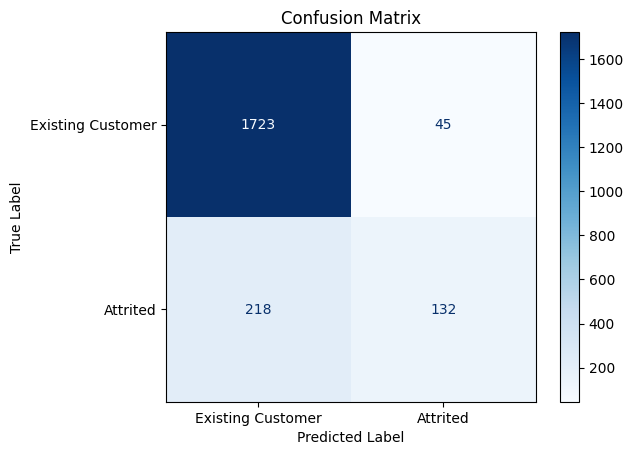

Number of Attrited Predictions: 177
Number of Existing Customer Predictions: 1941
Percent Attrited Predictions: 8.356940509915015
Percent Existing Customer Predictions: 91.643059490085

Accuracy: 0.8758262511803588


QDA RESULTS: 


c:\Users\water\anaconda3\envs\DSE6111\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


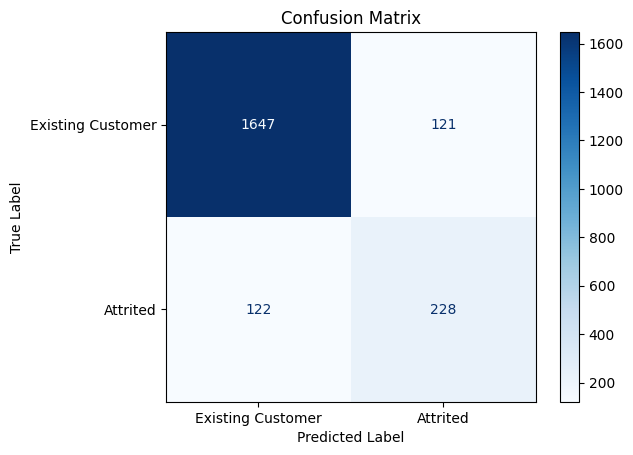

Number of Attrited Predictions: 349
Number of Existing Customer Predictions: 1769
Percent Attrited Predictions: 16.47780925401322
Percent Existing Customer Predictions: 83.52219074598678

Accuracy: 0.8852691218130312


KNN RESULTS: 
Number of neighbors selected: 15


c:\Users\water\anaconda3\envs\DSE6111\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


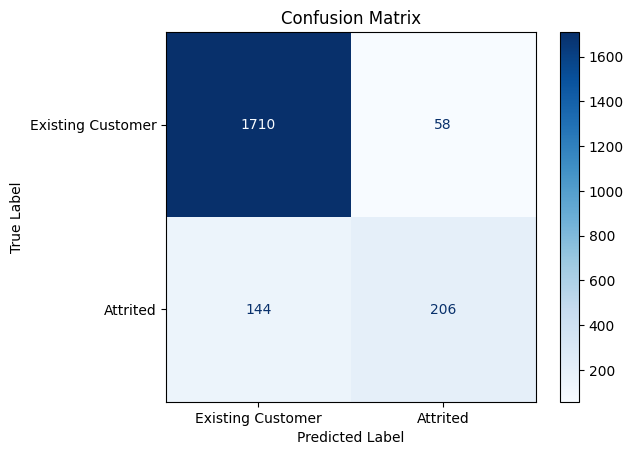

Number of Attrited Predictions: 264
Number of Existing Customer Predictions: 1854
Percent Attrited Predictions: 12.464589235127479
Percent Existing Customer Predictions: 87.53541076487252

Accuracy: 0.9046270066100094


In [277]:
training_data, eval_data = split_data(data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)

## Initial Findings

All of the models performed well, but I suspect this is from class imbalance. The next step would be to mitigate this as a possible source of error.

In [287]:
seed(42)
reduction_percentage = 65
remove_indices = []

for i in data[data['Attrition_Flag']==0].index.values:
    rand_num = randint(1,100)
    if rand_num <= reduction_percentage:
        remove_indices.append(i)

remove = set(remove_indices)
all_indices = set(data.index.values)

reduced_data = data.iloc[list(all_indices - remove)]
reduced_data.reset_index(inplace=True)

reduced_data.head(5)

,index,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Leveraged_Balance_Ratio,Relationship_Strength
0,0,0,0,0,0,0,0,3,777,1.335,1144,42,1.625,0.061,18.500000,0.676705,195
1,8193,0,0,1,1,2,0,3,0,0.559,5472,70,0.591,0.000,0.000000,0.000000,47
2,8194,0,1,4,0,1,0,2,1194,0.490,4684,82,0.907,0.557,14.560976,0.254836,38
3,3,0,1,0,2,1,0,1,2517,1.405,1171,20,2.333,0.760,125.850000,2.150196,102
4,8197,0,1,4,1,1,0,3,0,0.861,4783,91,0.685,0.000,0.000000,0.000000,40


4711 4711


Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.172336
         Iterations 9


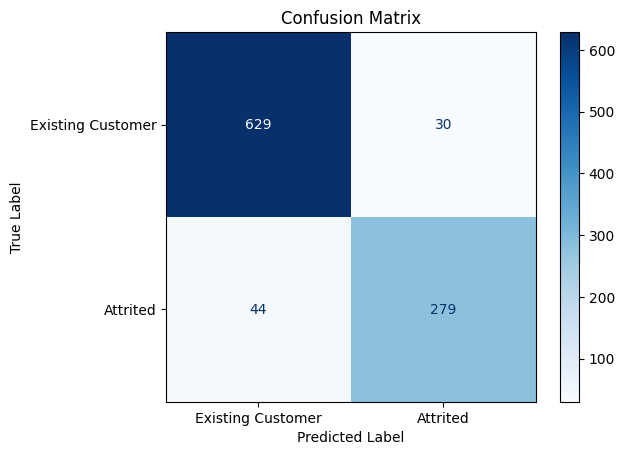

Number of Attrited Predictions: 309
Number of Existing Customer Predictions: 673
Percent Attrited Predictions: 31.466395112016293
Percent Existing Customer Predictions: 68.5336048879837

Accuracy: 0.924643584521385


QDA RESULTS: 


c:\Users\water\anaconda3\envs\DSE6111\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


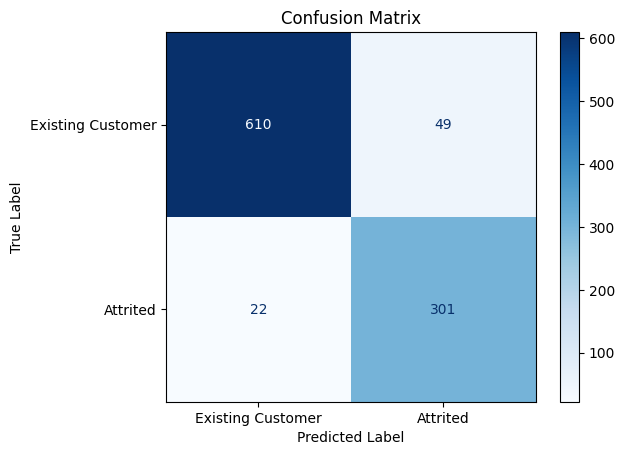

Number of Attrited Predictions: 350
Number of Existing Customer Predictions: 632
Percent Attrited Predictions: 35.64154786150713
Percent Existing Customer Predictions: 64.35845213849288

Accuracy: 0.9276985743380856


KNN RESULTS: 
Number of neighbors selected: 10


c:\Users\water\anaconda3\envs\DSE6111\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


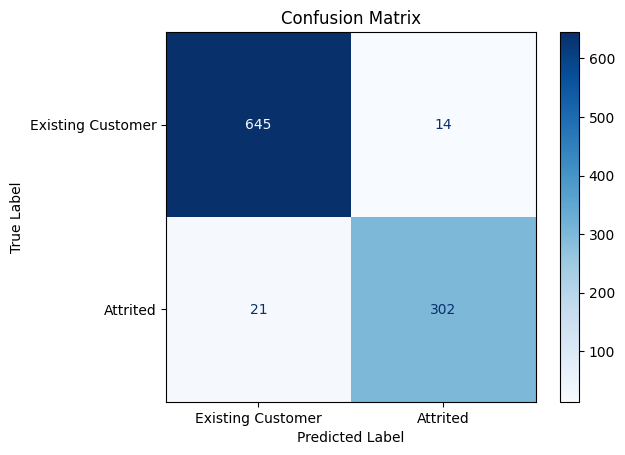

Number of Attrited Predictions: 316
Number of Existing Customer Predictions: 666
Percent Attrited Predictions: 32.17922606924644
Percent Existing Customer Predictions: 67.82077393075356

Accuracy: 0.9643584521384929


In [288]:
training_data, eval_data = split_data(reduced_data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)